In [1]:
import sys
sys.path.append('../')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from pathlib import Path

from src.models import LapSequenceTransformer, LapSequenceDataset

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️ Using device: {device}")

if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️ No GPU detected - training will be slower on CPU")

🖥️ Using device: cuda
✅ GPU: NVIDIA GeForce GTX 1650 Ti
💾 GPU Memory: 4.29 GB


In [2]:
# Load features from Notebook 2
df = pd.read_csv('../data/processed/features_engineered.csv')

print(f"✅ Loaded {len(df)} samples")
print(f"📊 Shape: {df.shape}")
print(f"\n🔴 Degradation Distribution:")
print(df['IsDegraded'].value_counts())
print(f"Degraded %: {df['IsDegraded'].mean()*100:.2f}%")

✅ Loaded 2639 samples
📊 Shape: (2639, 34)

🔴 Degradation Distribution:
IsDegraded
0    2075
1     564
Name: count, dtype: int64
Degraded %: 21.37%


In [3]:
# Create lap sequence dataset
print("Creating sequences...")
dataset = LapSequenceDataset(
    df, 
    sequence_length=10,  # Use 10 previous laps to predict next lap degradation
    target='IsDegraded'
)

print(f"✅ Created {len(dataset)} sequences")
print(f"📊 Input shape per sequence: {dataset.sequences.shape[1:]}") 
print(f"🎯 Sequence length: 10 laps")
print(f"🔢 Features per lap: 10")

Creating sequences...
✅ Created 2075 sequences
📊 Input shape per sequence: (10, 10)
🎯 Sequence length: 10 laps
🔢 Features per lap: 10


In [4]:
# Split dataset
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(
    dataset, 
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)  # For reproducibility
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"✅ Data split complete")
print(f"🏋️ Training samples: {len(train_dataset)}")
print(f"🧪 Testing samples: {len(test_dataset)}")
print(f"📦 Batches per epoch: {len(train_loader)}")

✅ Data split complete
🏋️ Training samples: 1660
🧪 Testing samples: 415
📦 Batches per epoch: 52


In [5]:
# Initialize Transformer model
model = LapSequenceTransformer(
    input_dim=10,
    d_model=64,
    nhead=4,
    num_layers=2,
    dim_feedforward=256,
    dropout=0.1
).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"✅ Model created")
print(f"🔢 Total parameters: {total_params:,}")
print(f"🎓 Trainable parameters: {trainable_params:,}")
print(f"💾 Model size: ~{total_params * 4 / 1024 / 1024:.2f} MB")

✅ Model created
🔢 Total parameters: 102,785
🎓 Trainable parameters: 102,785
💾 Model size: ~0.39 MB


In [6]:
# Loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': []
}

print("✅ Training setup complete")
print(f"🎯 Loss function: Binary Cross Entropy")
print(f"🔧 Optimizer: Adam (lr=0.001)")

✅ Training setup complete
🎯 Loss function: Binary Cross Entropy
🔧 Optimizer: Adam (lr=0.001)


In [7]:
num_epochs = 20

print("🚀 Starting training...\n")

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for sequences, labels in train_loader:
        sequences, labels = sequences.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(sequences)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        train_loss += loss.item()
        predictions = (outputs > 0.5).float()
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)
    
    # Testing phase
    model.eval()
    test_loss = 0
    test_correct = 0
    test_total = 0
    
    with torch.no_grad():
        for sequences, labels in test_loader:
            sequences, labels = sequences.to(device), labels.to(device)
            outputs = model(sequences)
            loss = criterion(outputs, labels)
            
            test_loss += loss.item()
            predictions = (outputs > 0.5).float()
            test_correct += (predictions == labels).sum().item()
            test_total += labels.size(0)
    
    # Calculate metrics
    train_loss_avg = train_loss / len(train_loader)
    train_acc = train_correct / train_total
    test_loss_avg = test_loss / len(test_loader)
    test_acc = test_correct / test_total
    
    # Save history
    history['train_loss'].append(train_loss_avg)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss_avg)
    history['test_acc'].append(test_acc)
    
    # Print progress
    print(f"Epoch {epoch+1:2d}/{num_epochs} | "
          f"Train Loss: {train_loss_avg:.4f} Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss_avg:.4f} Acc: {test_acc:.4f}")

print("\n✅ Training complete!")

🚀 Starting training...

Epoch  1/20 | Train Loss: 0.3607 Acc: 0.8584 | Test Loss: 0.3274 Acc: 0.8723
Epoch  2/20 | Train Loss: 0.3178 Acc: 0.8681 | Test Loss: 0.3124 Acc: 0.8843
Epoch  3/20 | Train Loss: 0.2965 Acc: 0.8928 | Test Loss: 0.2964 Acc: 0.8916
Epoch  4/20 | Train Loss: 0.2809 Acc: 0.8952 | Test Loss: 0.3396 Acc: 0.8627
Epoch  5/20 | Train Loss: 0.2915 Acc: 0.8934 | Test Loss: 0.2960 Acc: 0.8795
Epoch  6/20 | Train Loss: 0.2872 Acc: 0.8934 | Test Loss: 0.2851 Acc: 0.9012
Epoch  7/20 | Train Loss: 0.2756 Acc: 0.8928 | Test Loss: 0.2833 Acc: 0.8988
Epoch  8/20 | Train Loss: 0.2767 Acc: 0.8904 | Test Loss: 0.3041 Acc: 0.8940
Epoch  9/20 | Train Loss: 0.2662 Acc: 0.9018 | Test Loss: 0.2861 Acc: 0.8964
Epoch 10/20 | Train Loss: 0.2627 Acc: 0.9036 | Test Loss: 0.2901 Acc: 0.8916
Epoch 11/20 | Train Loss: 0.2585 Acc: 0.9078 | Test Loss: 0.2978 Acc: 0.8964
Epoch 12/20 | Train Loss: 0.2489 Acc: 0.9120 | Test Loss: 0.2969 Acc: 0.8916
Epoch 13/20 | Train Loss: 0.2593 Acc: 0.9066 | Test 

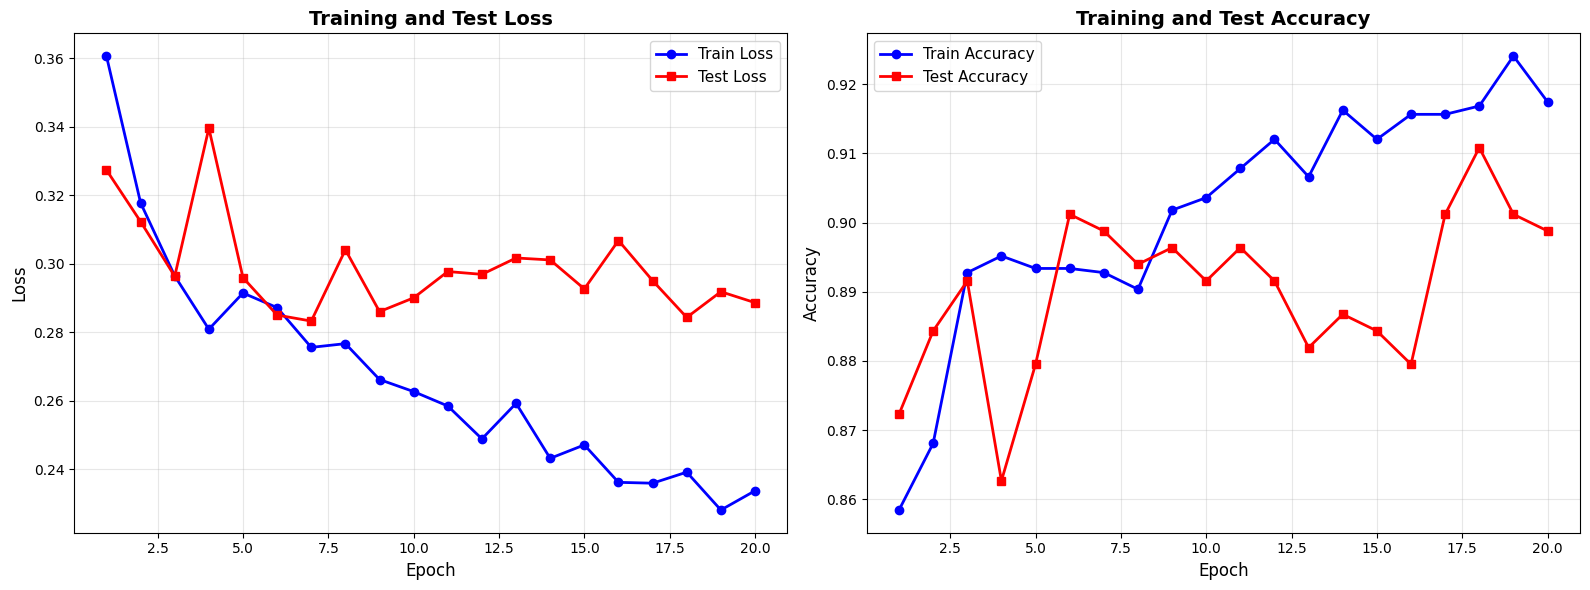

💾 Training history saved to results/figures/training_history.png


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

epochs_range = range(1, num_epochs + 1)

# Loss plot
ax1.plot(epochs_range, history['train_loss'], 'b-', linewidth=2, label='Train Loss', marker='o')
ax1.plot(epochs_range, history['test_loss'], 'r-', linewidth=2, label='Test Loss', marker='s')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Test Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(epochs_range, history['train_acc'], 'b-', linewidth=2, label='Train Accuracy', marker='o')
ax2.plot(epochs_range, history['test_acc'], 'r-', linewidth=2, label='Test Accuracy', marker='s')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Training and Test Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("💾 Training history saved to results/figures/training_history.png")

In [9]:
# Save model checkpoint
model_path = Path('../data/models/lap_transformer_v1.pth')
model_path.parent.mkdir(parents=True, exist_ok=True)

torch.save({
    'epoch': num_epochs,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_loss': history['train_loss'][-1],
    'test_loss': history['test_loss'][-1],
    'test_acc': history['test_acc'][-1],
}, model_path)

print(f"💾 Model saved to: {model_path}")
print(f"📊 Final test accuracy: {history['test_acc'][-1]:.4f}")
print(f"✅ Training pipeline complete!")

💾 Model saved to: ..\data\models\lap_transformer_v1.pth
📊 Final test accuracy: 0.8988
✅ Training pipeline complete!
